<a href="https://colab.research.google.com/github/cardinal-ship-it/Acend-NFT-Marketplace/blob/main/LSTM_using_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Read and load the data
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/g5XM0-gTrOquyZcBxcJAfw/StockData.csv')
df.drop(['Unnamed:0'], axis=1, implace = True)

In [ ]:
df.head()

,Date,Open,High,Low,Close
0,2018-03-27,173.68,175.15,166.92,168.340
1,2018-03-26,168.07,173.10,166.44,172.770
2,2018-03-23,168.39,169.92,164.94,164.940
3,2018-03-22,170.00,172.68,168.60,168.845
4,2018-03-21,175.04,175.09,171.26,171.270


In [ ]:
stock_data = df
# Convert the data column to dateline object
stock_data['Date'] = pd.to_datetime(stock_data['Date'])
print('information about the dataset', end = '\n')
print(stock_data.info())

information about the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9400 entries, 0 to 9399
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9400 non-null   datetime64[ns]
 1   Open    9400 non-null   float64       
 2   High    9400 non-null   float64       
 3   Low     9400 non-null   float64       
 4   Close   9400 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 367.3 KB
None


In [ ]:
print('first five element in the dataset', end = '\n')
print(stock_data.head(5))
print('last first element in the dataset', end = '\n')
print(stock_data.tail(5))

first five element in the dataset
        Date    Open    High     Low    Close
0 2018-03-27  173.68  175.15  166.92  168.340
1 2018-03-26  168.07  173.10  166.44  172.770
2 2018-03-23  168.39  169.92  164.94  164.940
3 2018-03-22  170.00  172.68  168.60  168.845
4 2018-03-21  175.04  175.09  171.26  171.270
last first element in the dataset
           Date   Open   High    Low  Close
9395 1980-12-18  26.63  26.75  26.63  26.63
9396 1980-12-17  25.87  26.00  25.87  25.87
9397 1980-12-16  25.37  25.37  25.25  25.25
9398 1980-12-15  27.38  27.38  27.25  27.25
9399 1980-12-12  28.75  28.87  28.75  28.75


In [ ]:
stock_date = stock_data.sort_values(by='Date')
print(stock_data.head())

        Date    Open    High     Low    Close
0 2018-03-27  173.68  175.15  166.92  168.340
1 2018-03-26  168.07  173.10  166.44  172.770
2 2018-03-23  168.39  169.92  164.94  164.940
3 2018-03-22  170.00  172.68  168.60  168.845
4 2018-03-21  175.04  175.09  171.26  171.270


In [ ]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler
price = stock_data[['High', 'Low', 'Open', 'Close']]
print(price.head[:5])

     High     Low    Open    Close
0  175.15  166.92  173.68  168.340
1  173.10  166.44  168.07  172.770
2  169.92  164.94  168.39  164.940
3  172.68  168.60  170.00  168.845
4  175.09  171.26  175.04  171.270


In [ ]:
Scalar = MinMaxScaler(feature_range=(-1,1))
price = Scalar.fit_transform(price)
print(price[:5])

[[-0.52725701 -0.54711939 -0.52969087 -0.54466792]
 [-0.53316521 -0.54851359 -0.54592139 -0.53184778]
 [-0.54233014 -0.55287044 -0.54499559 -0.55450731]
 [-0.53437568 -0.54223971 -0.54033763 -0.54320648]
 [-0.52742993 -0.53451356 -0.52575619 -0.53618868]]


In [ ]:
# Create test ahd training sets
train_window = 7
tw = train_window
import numpy as np

def create_in_out_sequences(price, tw):
  inout_seq = []
  L =len(price)
  print('length =', L)

  for i in range(L-tw):
    data_seq = price[i:i+tw]
    data_label = price[i+tw:i+tw+1][0][3]
    inout_seq.append((data_seq, data_label))

  data = inout_seq;
  print('size of data : ', len(data))

  test_set_size = 20
  train_set_size = len(data) - (test_set_size);
  print('size of test : ', test_set_size)
  print('size of train : ', train_set_size)

  train = data['train_set_size']
  test = data['test_set_size']
  train = train[:-(tw-1)]
  return train, test

train,test = create_in_out_sequences(price, train_window)

length = 9400
size of data :  9393
size of test :  20
size of train :  9373


In [ ]:
# Print the first 5 elements of the test data and the last five of the train set to confirm the formatting
print(test[5])
print([-1])

(array([[-0.94342532, -0.94298328, -0.9435548 , -0.94319201],
       [-0.94377117, -0.94336088, -0.9435548 , -0.94356822],
       [-0.9401686 , -0.94010776, -0.93993838, -0.94032701],
       [-0.93982275, -0.93935257, -0.93993838, -0.93957459],
       [-0.9445205 , -0.94408702, -0.94430702, -0.94429171],
       [-0.94270481, -0.94225714, -0.94248434, -0.94246853],
       [-0.93875639, -0.93827788, -0.93852074, -0.93850383]]), np.float64(-0.9341629286644481))
[-1]


In [ ]:
#LSTM and Forward
class LSTM(nn.Module):
  def __init__(self, input_size=4, hidden_layer_size=100, output_size=1):
    super().__init__()
    self.hidden_layer_size = hidden_layer_size
    self.lstm = nn.LSTM(input_size, hidden_layer_size)
    self.linear = nn.Linear(hidden_layer_size, output_size)

  def forward(self, input_seq):
    hidden_cell = (torch.zeros(1,1,self.hidden_layer_size),
                   torch.zeros(1,1,self.hidden_layer_size),
    )
    lstm_out, hidden_cell = self.lstm(input_seq.view(len(input_seq),1, -1), hidden_cell)
    predictions = self.linear(lstm_out.view(len(input_seq), -1))
    return predictions[-1]


In [ ]:
Model = LSTM()
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(Model.parameters(), lr=0.001)

In [ ]:
# Train the model
from tqdm.notebook import tqdm
epochs = 5
for i in tqdm(range(epochs)):
  epoch_loss = 0
  for seq, labels in tqdm(train):
    seq = torch.from_numpy(np.array(seq)).type(torch.FloatTensor)
    labels = torch.from_numpy(np.array(labels)).type(torch.FloatTensor)

    optimizer.zero_grad()

    y_pred = Model(seq)

    labels = labels.view(1)


    single_loss = loss_function(y_pred, labels)
    single_loss.backward()
    optimizer.step()

    epoch_loss += single_loss.item()

  average_loss = epoch_loss/len(train)
  print(f' epoch: {i:3} loss: {average_loss:.10f}')


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/9367 [00:00<?, ?it/s]

 epoch:   0 loss: 0.0005653029


  0%|          | 0/9367 [00:00<?, ?it/s]

 epoch:   1 loss: 0.0005379364


...

 epoch:   2 loss: 0.0005157627


  0%|          | 0/9367 [00:00<?, ?it/s]

 epoch:   3 loss: 0.0005138490


  0%|          | 0/9367 [00:00<?, ?it/s]

 epoch:   4 loss: 0.0005029585


In [ ]:
# the method will allow us predict the values using the trained model

Model.eval()
actual = []
pred = []
for seq, labels in test:
  seq = torch.from_numpy(np.array(seq)).type(torch.FloatTensor)
  labels = torch.from_numpy(np.array(labels)).type(torch.FloatTensor)
  actual.append(labels.item())
  with torch.no_grad():
    pred.append(Model(seq).item())
actual = np.array(actual)
pred = np.array(pred)

In [ ]:
#convert the predicted and actual data to tensor
pred = torch.from_numpy(np.array(pred)).type(torch.Tensor)
actual = torch.from_numpy(np.array(actual)).type(torch.Tensor)

print(pred)
print(actual)

tensor([-0.9388, -0.9384, -0.9384, -0.9389, -0.9386, -0.9382, -0.9377, -0.9375,
        -0.9376, -0.9372, -0.9370, -0.9371, -0.9382, -0.9387, -0.9391, -0.9396,
        -0.9401, -0.9403, -0.9405, -0.9398])
tensor([-0.9403, -0.9396, -0.9443, -0.9425, -0.9385, -0.9342, -0.9320, -0.9331,
        -0.9302, -0.9277, -0.9291, -0.9378, -0.9425, -0.9461, -0.9501, -0.9548,
        -0.9570, -0.9588, -0.9530, -0.9486])


In [ ]:
#To better understand analyze the accuracy of the models prediction values, we need to convert the normalized values into their scalar form

pred_new = Scalar.inverse_transform(np.c_[np.zeros (20), np.zeros(20), np.zeros(20), np.array(pred)])

print(pred_new [:,3])

[32.1519107  32.29501438 32.30152284 32.11071793 32.20010624 32.35729785
 32.52981317 32.61156022 32.56272619 32.69048557 32.78574385 32.718785
 32.35752441 32.18636845 32.04437697 31.88780325 31.70486616 31.62633215
 31.5604855  31.798106  ]


In [ ]:
actual_new = Scalar.inverse_transform(np.c_[np.zeros (20), np.zeros(20), np.zeros(20), np.array(actual)])
print(actual_new [:,3])

[31.62000906 31.87999722 30.24999931 30.88000154 32.24999068 33.75000481
 34.50000157 34.13000811 35.11999395 35.9999951  35.49999726 32.5000102
 30.88000154 29.63000693 28.25000795 26.62999928 25.86999268 25.2500003
 27.24999166 28.75000579]


In [ ]:
# lets evaluate the model

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(actual_new,pred_new)
print('Mean Absolute Error (MAE):', mae)

rmse = np.sqrt(mean_squared_error(actual_new, pred_new))
print('Root Mean Squared Error (RMSE):', rmse)


Mean Absolute Error (MAE): 0.6327006083354356
Root Mean Squared Error (RMSE): 1.5514104419106731


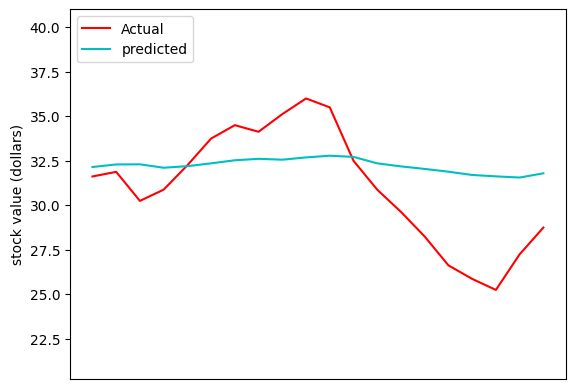

In [ ]:
# let us visualize the results to see how close they are to the values

fig, ax = plt.subplots()
ax.plot(actual_new[:,3], 'r-', label = 'Actual')
ax.plot(pred_new[:,3], 'c-', label = 'predicted')

ax.set_ylabel('stock value (dollars)')

ax.set_ylim(min(min(actual_new [:,3]), min(pred_new [:,3])) -5, max(max(actual_new [:,3]), max(pred_new [:,3])) +5)

plt.xticks([])

ax.legend(loc = 'upper left')

plt.show()

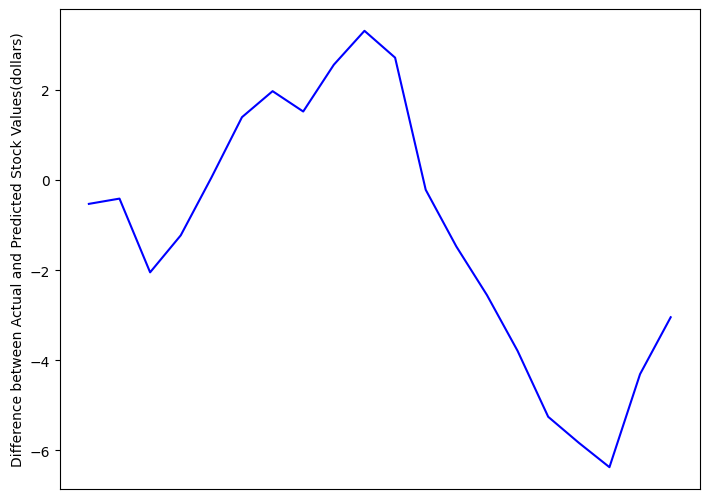

In [ ]:
# Let us plot the difference between the actual and the predicted values
difference = actual_new - pred_new

fig = plt.figure()
diffGraph = fig.add_axes([0,0,1,1])
diffGraph.plot(difference [:,3], 'b')
diffGraph.set_ylabel('Difference between Actual and Predicted Stock Values(dollars)')
plt.xticks([])
plt.show()

from the above plot we can see that the predicted value often seems to be lower than the actual value.